# RetailPulse

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
from sklearn.preprocessing import StandardScaler

pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')

## 1. Dataset Understanding

In [2]:
df = pd.read_csv('../data/raw/online_retail_II.csv', encoding='utf-8')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nData Types:')
print(df.dtypes)
df.head()

Shape: (1067371, 8)

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data Types:
Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


## 2. Missing Value Handling

In [3]:
print('Null counts:')
print(df.isnull().sum())

# drop rows with no Customer ID — unusable for customer-level analysis
df = df.dropna(subset=['Customer ID'])

# fill missing descriptions with 'Unknown'
df['Description'] = df['Description'].fillna('Unknown')

print('\nAfter handling missing values:', df.shape)

Null counts:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

After handling missing values: (824364, 8)


## 3. Duplicate Handling

In [4]:
print('Duplicate rows:', df.duplicated().sum())
df = df.drop_duplicates()
print('After removing duplicates:', df.shape)

Duplicate rows: 26479
After removing duplicates: (797885, 8)


## 4. Remove Cancelled Transactions

In [5]:
cancelled = df[df['Invoice'].astype(str).str.startswith('C')]
print('Cancelled transactions:', len(cancelled))

df = df[~df['Invoice'].astype(str).str.startswith('C')]
print('After removal:', df.shape)

Cancelled transactions: 18390
After removal: (779495, 8)


## 5. Invalid Quantity & Price

In [6]:
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]
print('After removing invalid quantity/price:', df.shape)

After removing invalid quantity/price: (779425, 8)


## 6. Date Conversion

In [7]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(df['InvoiceDate'].dtype)
df['InvoiceDate'].describe()

datetime64[us]


count                        779425
mean     2011-01-03 01:44:42.593476
min             2009-12-01 07:45:00
25%             2010-07-02 14:39:00
50%             2010-12-02 14:09:00
75%             2011-08-01 13:44:00
max             2011-12-09 12:50:00
Name: InvoiceDate, dtype: object

## 7. Time-Based Feature Engineering

In [8]:
df['Year']    = df['InvoiceDate'].dt.year
df['Month']   = df['InvoiceDate'].dt.month
df['Day']     = df['InvoiceDate'].dt.day
df['Weekday'] = df['InvoiceDate'].dt.day_name()
df['Hour']    = df['InvoiceDate'].dt.hour

df[['InvoiceDate','Year','Month','Day','Weekday','Hour']].head()

,InvoiceDate,Year,Month,Day,Weekday,Hour
0,2009-12-01 07:45:00,2009,12,1,Tuesday,7
1,2009-12-01 07:45:00,2009,12,1,Tuesday,7
2,2009-12-01 07:45:00,2009,12,1,Tuesday,7
3,2009-12-01 07:45:00,2009,12,1,Tuesday,7
4,2009-12-01 07:45:00,2009,12,1,Tuesday,7


## 8. New Feature Engineering

In [9]:
df['TotalPrice'] = df['Quantity'] * df['Price']

# Customer Lifetime Value — total spend per customer
clv = df.groupby('Customer ID')['TotalPrice'].sum().rename('CustomerLifetimeValue')
df  = df.merge(clv, on='Customer ID', how='left')

# Recency — days since last purchase relative to dataset max date
snapshot_date = df['InvoiceDate'].max()
last_purchase = df.groupby('Customer ID')['InvoiceDate'].max()
recency_map   = (snapshot_date - last_purchase).dt.days.rename('RecencyDays')
df = df.merge(recency_map, on='Customer ID', how='left')

df[['Customer ID','TotalPrice','CustomerLifetimeValue','RecencyDays']].head()

,Customer ID,TotalPrice,CustomerLifetimeValue,RecencyDays
0,13085.00,83.40,2433.28,157
1,13085.00,81.00,2433.28,157
2,13085.00,81.00,2433.28,157
3,13085.00,100.80,2433.28,157
4,13085.00,30.00,2433.28,157


## 9. Outlier Analysis

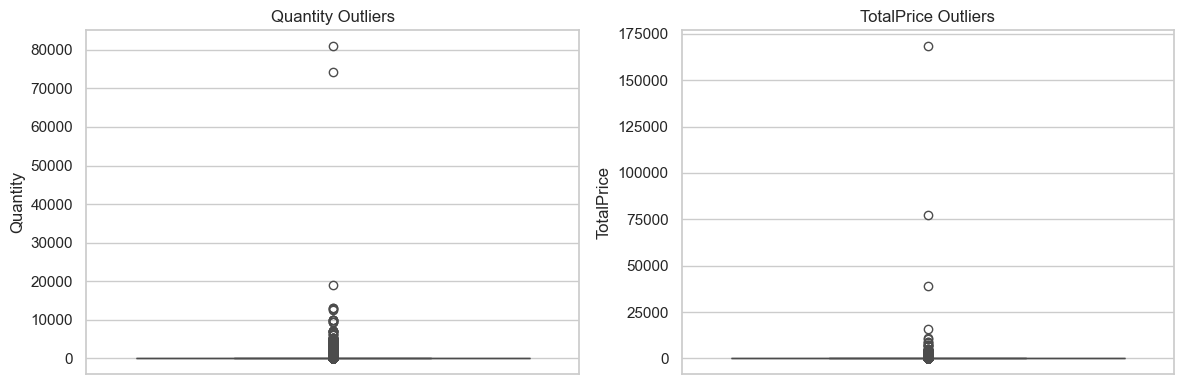

Quantity stats:
count   779425.00
mean        13.49
std        145.86
min          1.00
25%          2.00
50%          6.00
75%         12.00
max      80995.00
Name: Quantity, dtype: float64

TotalPrice stats:
count   779425.00
mean        22.29
std        227.43
min          0.00
25%          4.95
50%         12.48
75%         19.80
max     168469.60
Name: TotalPrice, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=df['Quantity'],   ax=axes[0]).set_title('Quantity Outliers')
sns.boxplot(y=df['TotalPrice'], ax=axes[1]).set_title('TotalPrice Outliers')

plt.tight_layout()
plt.show()

print('Quantity stats:')
print(df['Quantity'].describe())
print('\nTotalPrice stats:')
print(df['TotalPrice'].describe())

In [ ]:
# cap extreme outliers at 99th percentile
q99_qty   = df['Quantity'].quantile(0.99)
q99_price = df['TotalPrice'].quantile(0.99)

df = df[(df['Quantity'] <= q99_qty) & (df['TotalPrice'] <= q99_price)]
print('After capping outliers:', df.shape)

## 10. Data Standardization

In [11]:
print('Unique countries before:', df['Country'].nunique())

df['Country']     = df['Country'].str.strip().str.title()
df['Description'] = df['Description'].str.strip().str.title()

print('Unique countries after:', df['Country'].nunique())
df['Country'].value_counts().head(10)

Unique countries before: 41
Unique countries after: 41


Country
United Kingdom    700388
Germany            16432
Eire               15565
France             13511
Netherlands         5085
Spain               3662
Belgium             3055
Switzerland         3005
Portugal            2356
Australia           1789
Name: count, dtype: int64

## 11. RFM Dataset

In [12]:
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate',  lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice',      'nunique'),
    Monetary  = ('TotalPrice',   'sum')
).reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.00,325,12,77556.46
1,12347.00,1,8,4921.53
2,12348.00,74,5,2019.40
3,12349.00,18,4,4428.69
4,12350.00,309,1,334.40


## 12. Time-Series Dataset

In [13]:
daily_sales = (
    df.groupby(df['InvoiceDate'].dt.date)['TotalPrice']
    .sum()
    .reset_index()
    .rename(columns={'InvoiceDate': 'Date', 'TotalPrice': 'DailySales'})
)

daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])
daily_sales.head()

,Date,DailySales
0,2009-12-01,43894.87
1,2009-12-02,52762.06
2,2009-12-03,67413.62
3,2009-12-04,33913.81
4,2009-12-05,9803.05


## 13. Data Validation

In [14]:
checks = {
    'No missing Customer IDs' : df['Customer ID'].isnull().sum() == 0,
    'No duplicates'           : df.duplicated().sum() == 0,
    'No negative quantities'  : (df['Quantity'] <= 0).sum() == 0,
    'No invalid prices'       : (df['Price'] <= 0).sum() == 0,
    'InvoiceDate is datetime' : str(df['InvoiceDate'].dtype) == 'datetime64[ns]',
}

for check, result in checks.items():
    status = 'OK' if result else 'NOT OK'
    print(f'{status}  {check}')

OK  No missing Customer IDs
OK  No duplicates
OK  No negative quantities
OK  No invalid prices
NOT OK  InvoiceDate is datetime


## 14. Export Cleaned Data

In [15]:
df.to_csv('../data/processed/cleaned_transactions.csv', index=False)
rfm.to_csv('../data/processed/rfm_dataset.csv', index=False)
daily_sales.to_csv('../data/processed/daily_sales.csv', index=False)

print('Exports done.')
print(f'  cleaned_transactions : {df.shape}')
print(f'  rfm_dataset          : {rfm.shape}')
print(f'  daily_sales          : {daily_sales.shape}')

Exports done.
  cleaned_transactions : (779425, 16)
  rfm_dataset          : (5878, 4)
  daily_sales          : (604, 2)


## 15. Refer Another Dataset

In [16]:
df_new      = pd.read_csv('../data/processed/cleaned_transactions.csv', parse_dates=['InvoiceDate'])
rfm         = pd.read_csv('../data/processed/rfm_dataset.csv')
daily_sales = pd.read_csv('../data/processed/daily_sales.csv', parse_dates=['Date'])

snapshot_date = df_new['InvoiceDate'].max()

## 16. New Dataset Overview

In [17]:
print('Shape:', df_new.shape)
print('\nColumn Info:')
df_new.info()
print('\nStatistical Summary:')
df_new.describe()

Shape: (779425, 16)

Column Info:
<class 'pandas.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Invoice                779425 non-null  int64         
 1   StockCode              779425 non-null  str           
 2   Description            779425 non-null  str           
 3   Quantity               779425 non-null  int64         
 4   InvoiceDate            779425 non-null  datetime64[us]
 5   Price                  779425 non-null  float64       
 6   Customer ID            779425 non-null  float64       
 7   Country                779425 non-null  str           
 8   Year                   779425 non-null  int64         
 9   Month                  779425 non-null  int64         
 10  Day                    779425 non-null  int64         
 11  Weekday                779425 non-null  str           
 12  Hour                 

,Invoice,Quantity,InvoiceDate,Price,Customer ID,Year,Month,Day,Hour,TotalPrice,CustomerLifetimeValue,RecencyDays
count,779425.00,779425.00,779425,779425.00,779425.00,779425.00,779425.00,779425.00,779425.00,779425.00,779425.00,779425.00
mean,537426.83,13.49,2011-01-03 01:44:42.593476,3.22,15320.36,2010.43,7.42,15.39,12.79,22.29,20790.20,81.61
min,489434.00,1.00,2009-12-01 07:45:00,0.00,12346.00,2009.00,1.00,1.00,6.00,0.00,2.95,0.00
25%,514483.00,2.00,2010-07-02 14:39:00,1.25,13971.00,2010.00,5.00,8.00,11.00,4.95,1728.99,5.00
50%,536754.00,6.00,2010-12-02 14:09:00,1.95,15247.00,2010.00,8.00,15.00,13.00,12.48,4467.66,21.00
75%,561995.00,12.00,2011-08-01 13:44:00,3.75,16794.00,2011.00,11.00,23.00,14.00,19.80,11383.03,73.00
max,581587.00,80995.00,2011-12-09 12:50:00,10953.50,18287.00,2011.00,12.00,31.00,20.00,168469.60,580987.04,738.00
std,26901.63,145.86,NaN,29.68,1695.69,0.57,3.42,8.66,2.29,227.43,61575.13,138.02


## 17. Sales Analysis

In [18]:
print(f'Total Revenue   : £{df["TotalPrice"].sum():,.2f}')
print(f'Average Revenue : £{df["TotalPrice"].mean():,.2f}')
print(f'Median Revenue  : £{df["TotalPrice"].median():,.2f}')

Total Revenue   : £17,374,804.27
Average Revenue : £22.29
Median Revenue  : £12.48


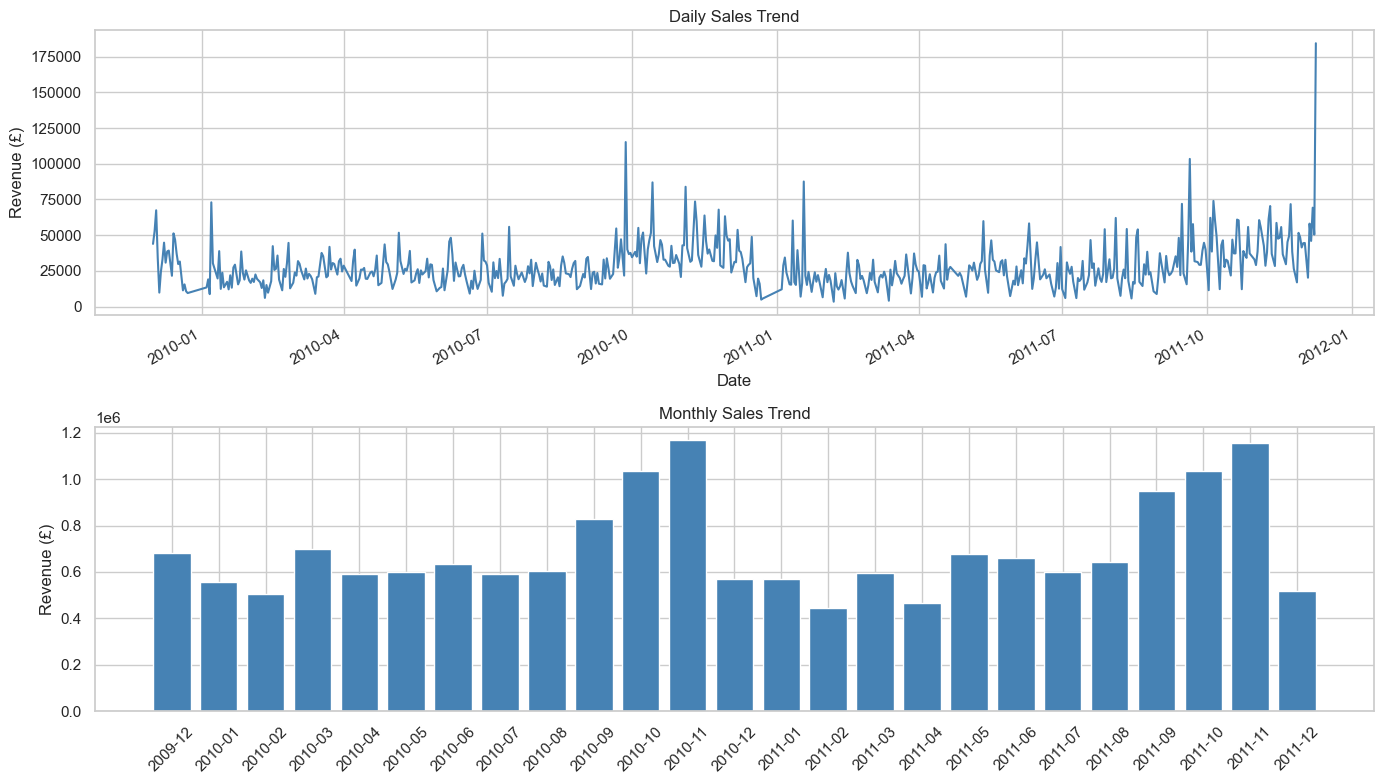

Highest sales month:
Year               2010
Month                11
TotalPrice   1166460.02
Period          2010-11
Name: 11, dtype: object

Lowest sales month:
Year              2011
Month                2
TotalPrice   446084.92
Period         2011-02
Name: 14, dtype: object


In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

daily_sales.plot(x='Date', y='DailySales', ax=axes[0], legend=False, color='steelblue')
axes[0].set_title('Daily Sales Trend')
axes[0].set_ylabel('Revenue (£)')

monthly = df.groupby(['Year', 'Month'])['TotalPrice'].sum().reset_index()
monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)
axes[1].bar(monthly['Period'], monthly['TotalPrice'], color='steelblue')
axes[1].set_title('Monthly Sales Trend')
axes[1].set_ylabel('Revenue (£)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Highest sales month:')
print(monthly.loc[monthly['TotalPrice'].idxmax()])
print('\nLowest sales month:')
print(monthly.loc[monthly['TotalPrice'].idxmin()])

## 18. Time-Based Analysis

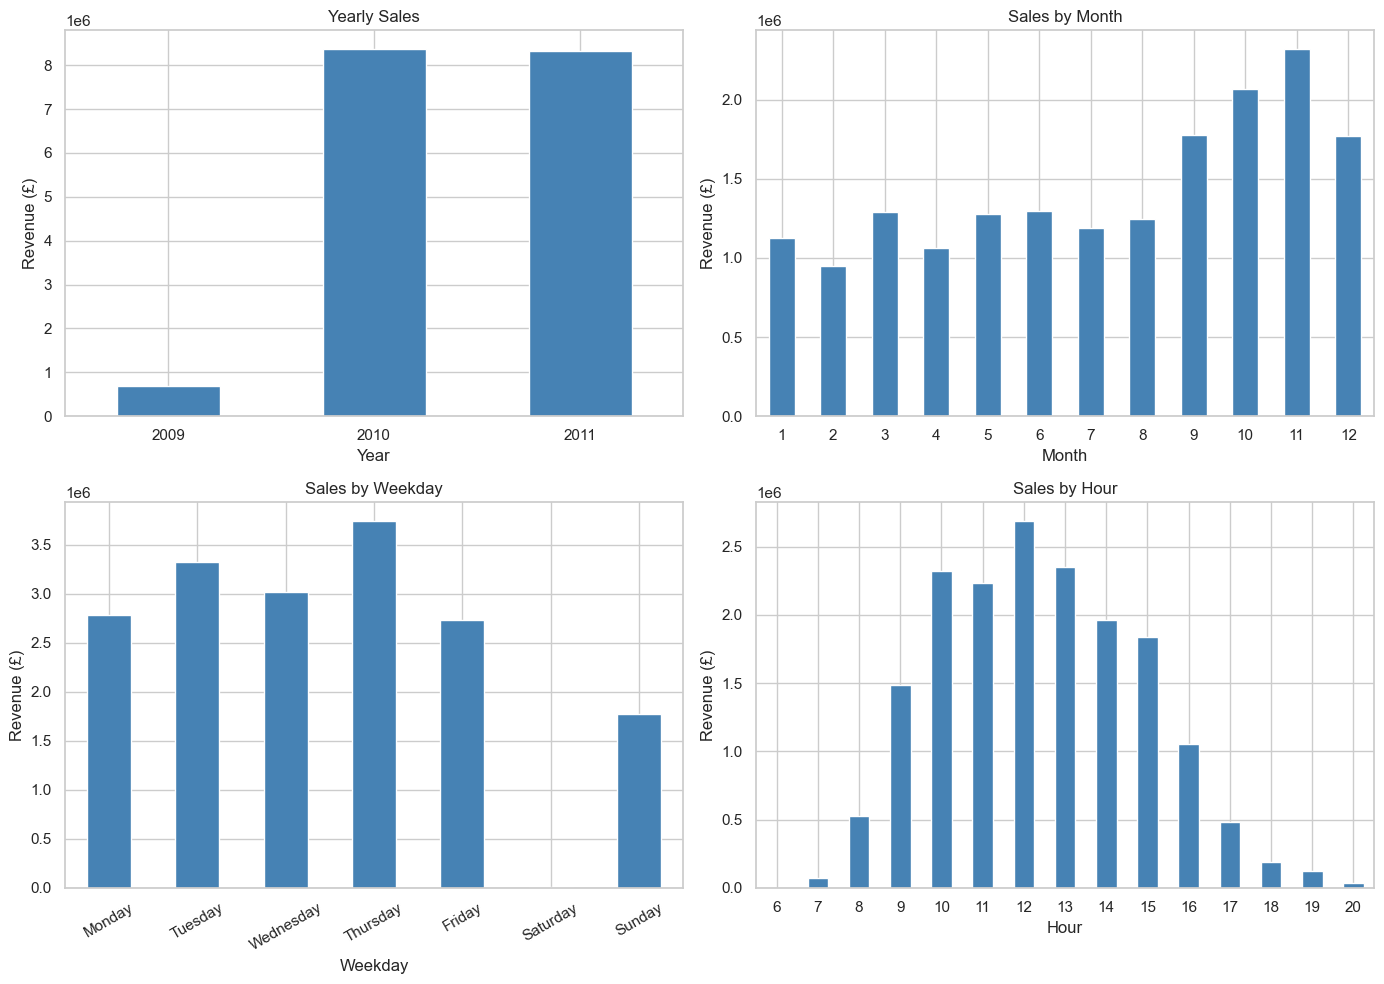

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df_new.groupby('Year')['TotalPrice'].sum().plot(kind='bar', ax=axes[0, 0], rot=0, color='steelblue')
axes[0, 0].set_title('Yearly Sales')
axes[0, 0].set_ylabel('Revenue (£)')

df_new.groupby('Month')['TotalPrice'].sum().plot(kind='bar', ax=axes[0, 1], rot=0, color='steelblue')
axes[0, 1].set_title('Sales by Month')
axes[0, 1].set_ylabel('Revenue (£)')

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_new.groupby('Weekday')['TotalPrice'].sum().reindex(day_order).plot(kind='bar', ax=axes[1, 0], rot=30, color='steelblue')
axes[1, 0].set_title('Sales by Weekday')
axes[1, 0].set_ylabel('Revenue (£)')

df_new.groupby('Hour')['TotalPrice'].sum().plot(kind='bar', ax=axes[1, 1], rot=0, color='steelblue')
axes[1, 1].set_title('Sales by Hour')
axes[1, 1].set_ylabel('Revenue (£)')

plt.tight_layout()
plt.show()

In [21]:
df_new['IsWeekend'] = df_new['Weekday'].isin(['Saturday', 'Sunday'])
df_new.groupby('IsWeekend')['TotalPrice'].agg(['sum', 'mean']).rename(index={False: 'Weekday', True: 'Weekend'})

,sum,mean
IsWeekend,,
Weekday,15596332.17,24.04
Weekend,1778472.10,13.62


## 19. Product Analysis

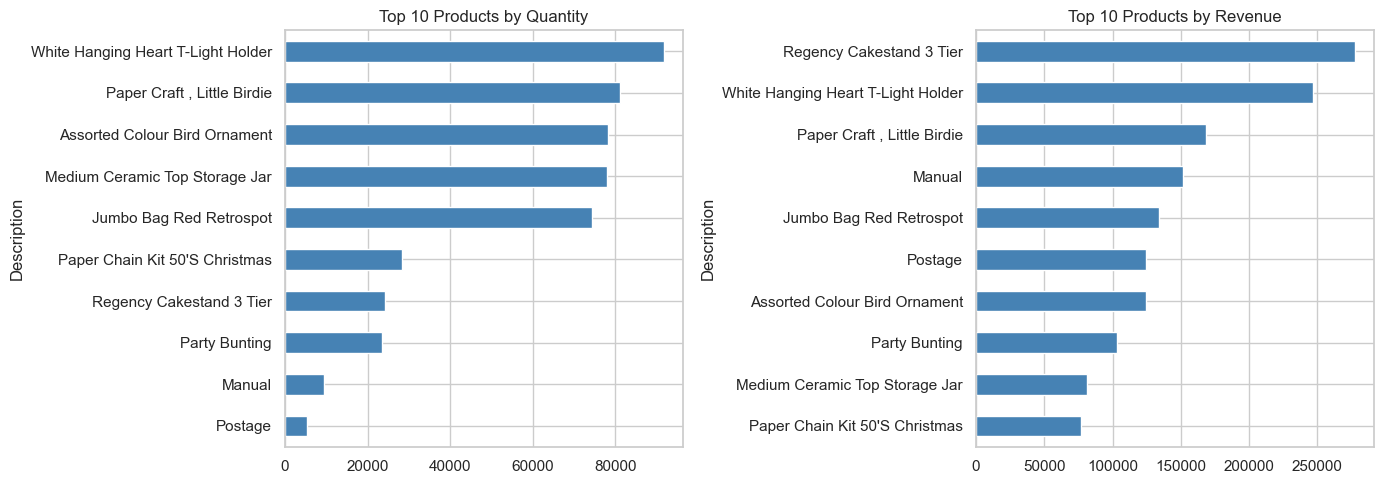

Least selling products:


,TotalQty,TotalRevenue
Description,,
Hollyhock Square Handy Tin,1,1.25
Set 36 Colouring Pencils Doiley,1,1.25
White Scandinavian Heart Christmas,1,1.25
Cat With Sunglasses Blank Card,5,0.95
Owls Charlotte Bag,1,0.85
Cat W Sunglasses Blank Card,4,0.76
Set 12 Colouring Pencils Doiley,1,0.65
Pink Heart Christmas Decoration,1,0.38
Happy Birthday Ginger Cat Card,2,0.38


In [22]:
product_stats = df_new.groupby('Description').agg(
    TotalQty     = ('Quantity',   'sum'),
    TotalRevenue = ('TotalPrice', 'sum'),
    Orders       = ('Invoice',    'nunique')
).sort_values('TotalRevenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

product_stats['TotalQty'].head(10).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Products by Quantity')

product_stats['TotalRevenue'].head(10).sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Products by Revenue')

plt.tight_layout()
plt.show()

print('Least selling products:')
product_stats.tail(10)[['TotalQty', 'TotalRevenue']]

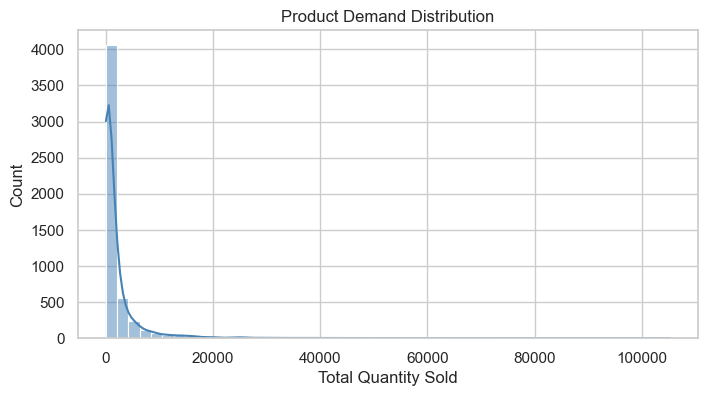

In [23]:
plt.figure(figsize=(8, 4))
sns.histplot(product_stats['TotalQty'], bins=50, kde=True, color='steelblue')
plt.title('Product Demand Distribution')
plt.xlabel('Total Quantity Sold')
plt.show()

## 20. Customer Analysis

In [24]:
customer_stats = df_new.groupby('Customer ID').agg(
    TotalRevenue = ('TotalPrice', 'sum'),
    Orders       = ('Invoice',    'nunique'),
    AvgOrderVal  = ('TotalPrice', 'mean')
).sort_values('TotalRevenue', ascending=False)

print('Top 10 customers by revenue:')
print(customer_stats.head(10))
print(f'\nRepeat customers (>1 order): {(customer_stats["Orders"] > 1).sum()}')

Top 10 customers by revenue:
             TotalRevenue  Orders  AvgOrderVal
Customer ID                                   
18102.00        580987.04     145       558.64
14646.00        528602.52     151       137.34
14156.00        313437.62     156        77.62
14911.00        291420.81     398        26.31
17450.00        244784.25      51       582.82
13694.00        195640.69     143       128.80
17511.00        172132.87      60        92.15
16446.00        168472.50       2     56157.50
16684.00        147142.77      55       204.93
12415.00        144458.37      28       156.00

Repeat customers (>1 order): 4255


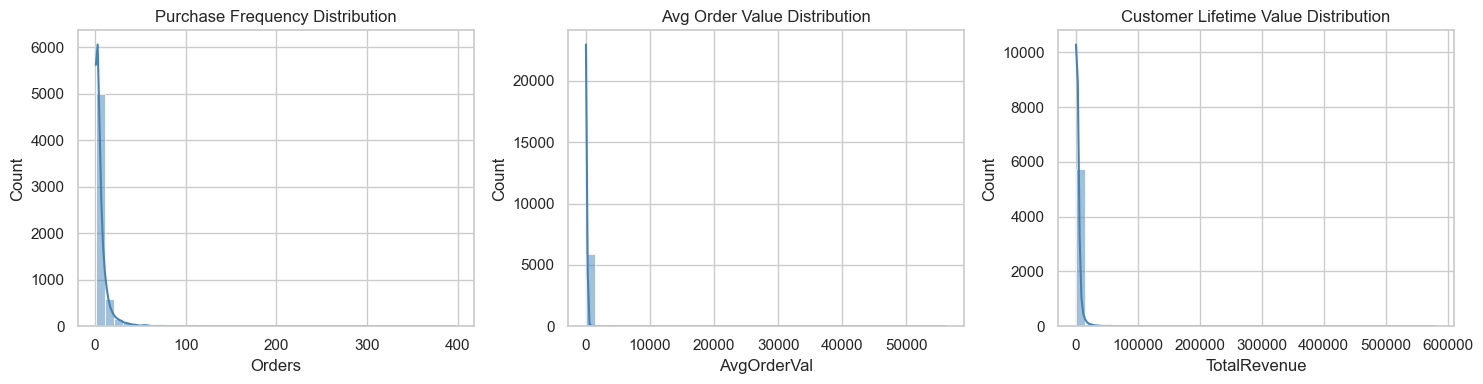

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(customer_stats['Orders'],       bins=40, ax=axes[0], kde=True, color='steelblue')
axes[0].set_title('Purchase Frequency Distribution')

sns.histplot(customer_stats['AvgOrderVal'],  bins=40, ax=axes[1], kde=True, color='steelblue')
axes[1].set_title('Avg Order Value Distribution')

sns.histplot(customer_stats['TotalRevenue'], bins=40, ax=axes[2], kde=True, color='steelblue')
axes[2].set_title('Customer Lifetime Value Distribution')

plt.tight_layout()
plt.show()

## 21. Country / Region Analysis

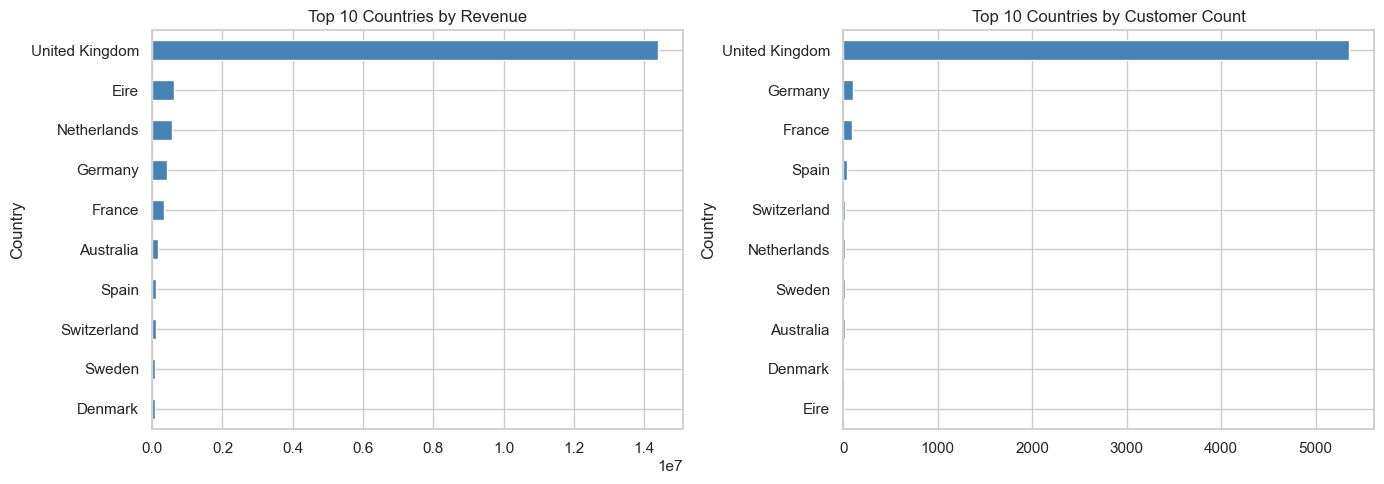

,Revenue,Customers,Orders,AvgOrderVal
Country,,,,
United Kingdom,14389234.92,5350,33541,429.00
Eire,616570.54,5,567,1087.43
Netherlands,554038.09,22,228,2429.99
Germany,425019.71,107,789,538.68
France,348768.96,95,614,568.03
Australia,169283.46,15,95,1781.93
Spain,108332.49,41,154,703.46
Switzerland,100061.94,22,90,1111.80
Sweden,91515.82,19,104,879.96


In [26]:
country_stats = df_new.groupby('Country').agg(
    Revenue   = ('TotalPrice',  'sum'),
    Customers = ('Customer ID', 'nunique'),
    Orders    = ('Invoice',     'nunique')
).sort_values('Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

country_stats['Revenue'].head(10).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Countries by Revenue')

country_stats['Customers'].head(10).sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Countries by Customer Count')

plt.tight_layout()
plt.show()

country_stats['AvgOrderVal'] = country_stats['Revenue'] / country_stats['Orders']
country_stats.head(10)

## 22. RFM Analysis

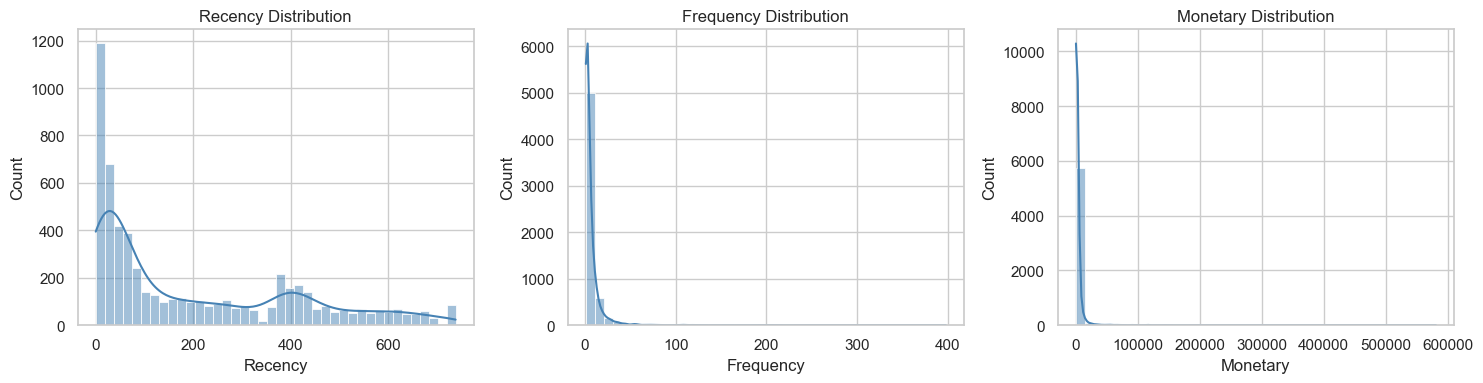

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm['Recency'],   bins=40, ax=axes[0], kde=True, color='steelblue').set_title('Recency Distribution')
sns.histplot(rfm['Frequency'], bins=40, ax=axes[1], kde=True, color='steelblue').set_title('Frequency Distribution')
sns.histplot(rfm['Monetary'],  bins=40, ax=axes[2], kde=True, color='steelblue').set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

In [28]:
recency_thresh  = rfm['Recency'].quantile(0.25)
inactive_thresh = rfm['Recency'].quantile(0.75)

print(f'Recently active customers (recency < {recency_thresh:.0f} days) : {(rfm["Recency"] < recency_thresh).sum()}')
print(f'Inactive customers (recency > {inactive_thresh:.0f} days)        : {(rfm["Recency"] > inactive_thresh).sum()}')
print(f'\nHighly frequent customers (top 10%): {(rfm["Frequency"] >= rfm["Frequency"].quantile(0.90)).sum()}')
print(f'High-value customers (top 10%)     : {(rfm["Monetary"]  >= rfm["Monetary"].quantile(0.90)).sum()}')

Recently active customers (recency < 25 days) : 1464
Inactive customers (recency > 379 days)        : 1459

Highly frequent customers (top 10%): 649
High-value customers (top 10%)     : 588


## 23. Customer Segmentation Insights

In [29]:
r_thresh = rfm['Recency'].quantile(0.33)
f_thresh = rfm['Frequency'].quantile(0.66)
m_thresh = rfm['Monetary'].quantile(0.66)

rfm['Segment'] = 'Others'
rfm.loc[(rfm['Recency'] <= r_thresh) & (rfm['Frequency'] >= f_thresh) & (rfm['Monetary'] >= m_thresh), 'Segment'] = 'VIP'
rfm.loc[(rfm['Recency'] > rfm['Recency'].quantile(0.75)) & (rfm['Frequency'] <= 2), 'Segment'] = 'At-Risk'
rfm.loc[(rfm['Frequency'] == 1) & (rfm['Monetary'] < rfm['Monetary'].quantile(0.33)), 'Segment'] = 'Low-Engagement'

print(rfm['Segment'].value_counts())

rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

Segment
Others            3054
Low-Engagement    1354
VIP               1036
At-Risk            434
Name: count, dtype: int64


,Recency,Frequency,Monetary
Segment,,,
At-Risk,489.23,1.73,815.81
Low-Engagement,364.74,1.00,212.56
Others,149.63,4.92,1905.96
VIP,13.89,19.16,10532.95


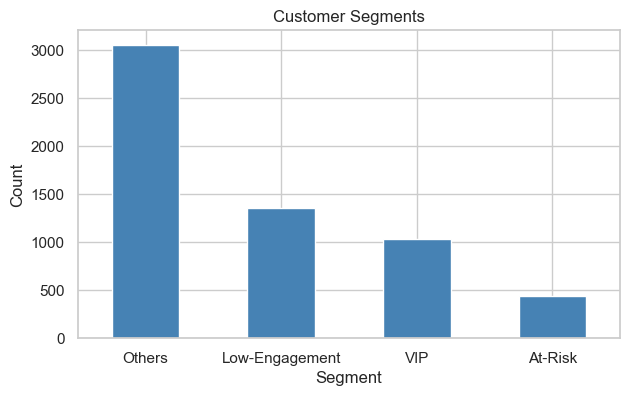

In [30]:
plt.figure(figsize=(7, 4))
rfm['Segment'].value_counts().plot(kind='bar', color='steelblue', rot=0)
plt.title('Customer Segments')
plt.ylabel('Count')
plt.show()

## 24. Basket / Order Analysis

In [31]:
basket = df_new.groupby('Invoice').agg(
    BasketSize    = ('Quantity',   'sum'),
    UniqueItems   = ('StockCode',  'nunique'),
    BasketRevenue = ('TotalPrice', 'sum')
)

print(f'Avg basket size (qty)   : {basket["BasketSize"].mean():.1f}')
print(f'Avg unique items/order  : {basket["UniqueItems"].mean():.1f}')
print(f'Avg revenue per invoice : £{basket["BasketRevenue"].mean():.2f}')

bulk_thresh = basket['BasketSize'].quantile(0.99)
print(f'\nBulk orders (qty > {bulk_thresh:.0f}): {(basket["BasketSize"] > bulk_thresh).sum()}')

Avg basket size (qty)   : 284.4
Avg unique items/order  : 20.8
Avg revenue per invoice : £469.98

Bulk orders (qty > 2258): 370


## 25. Outlier Analysis

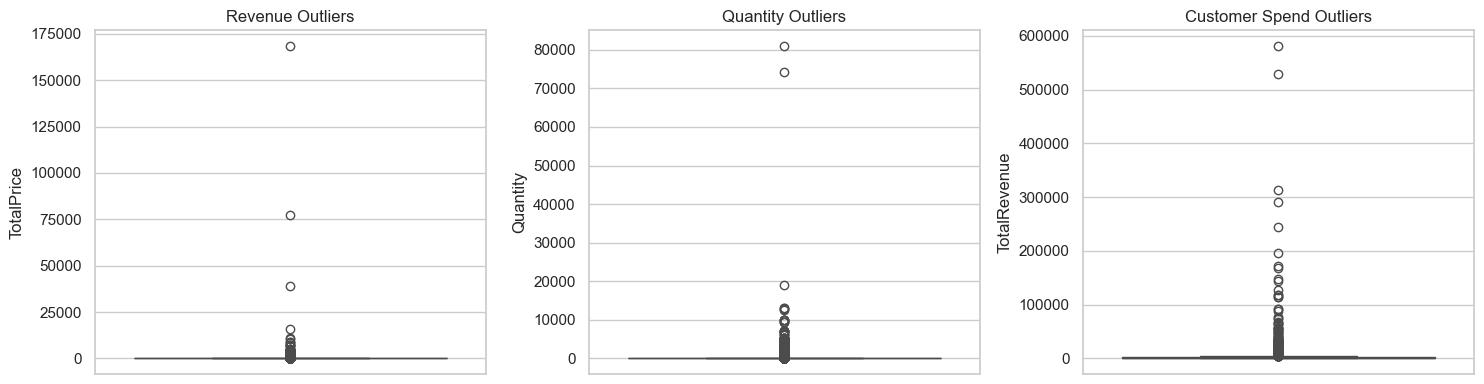

Top 5 customers by spend:
             TotalRevenue  Orders  AvgOrderVal
Customer ID                                   
18102.00        580987.04     145       558.64
14646.00        528602.52     151       137.34
14156.00        313437.62     156        77.62
14911.00        291420.81     398        26.31
17450.00        244784.25      51       582.82

These are likely wholesale/B2B customers — business-valid outliers.


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(y=df_new['TotalPrice'],               ax=axes[0]).set_title('Revenue Outliers')
sns.boxplot(y=df_new['Quantity'],                 ax=axes[1]).set_title('Quantity Outliers')
sns.boxplot(y=customer_stats['TotalRevenue'], ax=axes[2]).set_title('Customer Spend Outliers')

plt.tight_layout()
plt.show()

print('Top 5 customers by spend:')
print(customer_stats.head())
print('\nThese are likely wholesale/B2B customers — business-valid outliers.')

## 26. Correlation Analysis

Quantity vs TotalPrice correlation: 0.827
Frequency vs Monetary correlation : 0.628


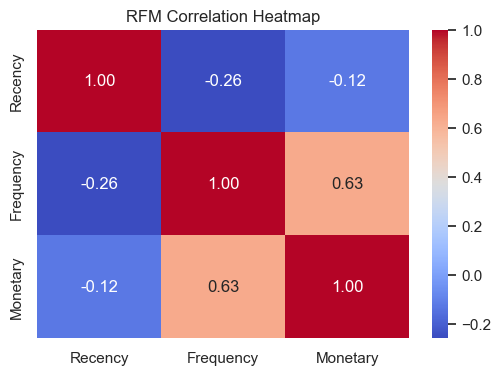

In [33]:
print('Quantity vs TotalPrice correlation:', df_new[['Quantity', 'TotalPrice']].corr().iloc[0, 1].round(3))
print('Frequency vs Monetary correlation :', rfm[['Frequency', 'Monetary']].corr().iloc[0, 1].round(3))

plt.figure(figsize=(6, 4))
sns.heatmap(rfm[['Recency', 'Frequency', 'Monetary']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('RFM Correlation Heatmap')
plt.show()

## 27. Forecasting Preparation Analysis

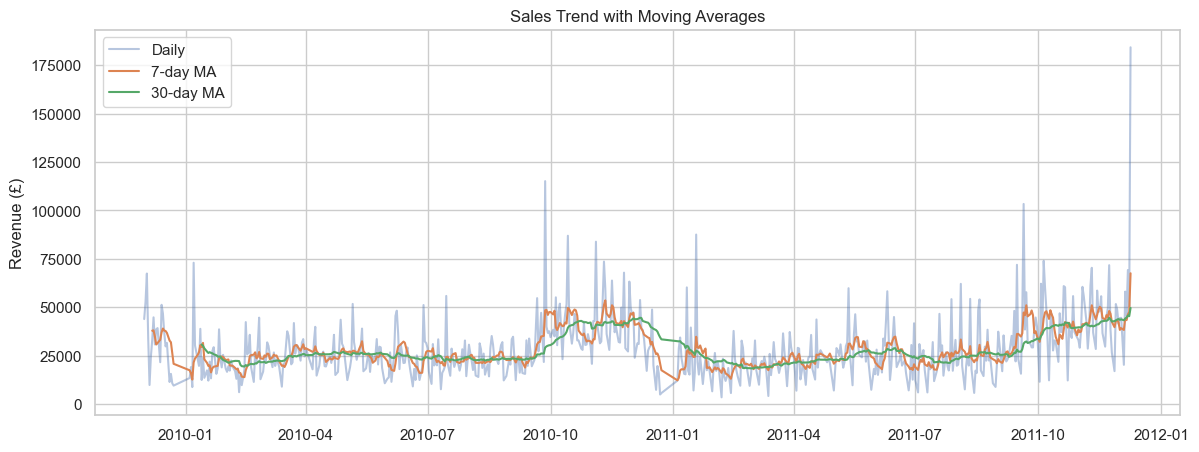

Top 5 spike days:
Date
2011-12-09   184347.66
2010-09-27   115172.24
2011-09-20   103377.68
2011-01-18    87559.21
2010-10-14    86945.13
Name: DailySales, dtype: float64

Top 5 dip days:
Date
2011-02-06   3439.67
2011-03-13   4117.22
2010-12-22   4886.52
2010-12-23   5644.77
2011-02-13   5645.48
Name: DailySales, dtype: float64


In [34]:
ds = daily_sales.set_index('Date').sort_index()
ds['MA7']  = ds['DailySales'].rolling(7).mean()
ds['MA30'] = ds['DailySales'].rolling(30).mean()

plt.figure(figsize=(14, 5))
plt.plot(ds['DailySales'], alpha=0.4, label='Daily')
plt.plot(ds['MA7'],  label='7-day MA')
plt.plot(ds['MA30'], label='30-day MA')
plt.title('Sales Trend with Moving Averages')
plt.ylabel('Revenue (£)')
plt.legend()
plt.show()

print('Top 5 spike days:')
print(ds['DailySales'].nlargest(5))
print('\nTop 5 dip days:')
print(ds['DailySales'].nsmallest(5))

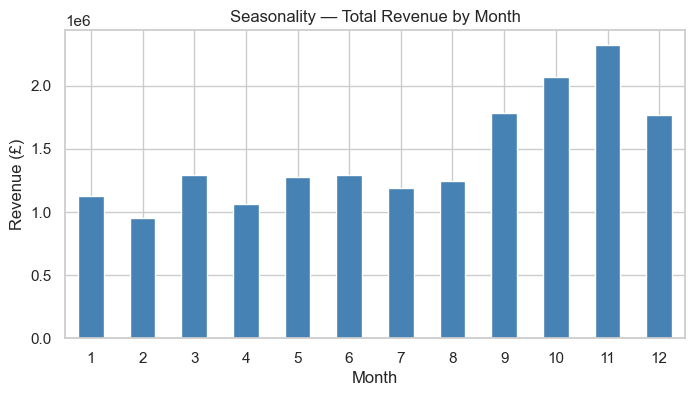

In [35]:
plt.figure(figsize=(8, 4))
df.groupby('Month')['TotalPrice'].sum().plot(kind='bar', rot=0, color='steelblue')
plt.title('Seasonality — Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.show()

## 28. Churn Analysis Preparation

In [36]:
churned = rfm[rfm['Recency'] > 90]
active  = rfm[rfm['Recency'] <= 90]

print(f'Active customers  (recency <= 90 days): {len(active)}')
print(f'Churned customers (recency >  90 days): {len(churned)}')

print('\nActive vs Churned — avg behaviour:')
pd.DataFrame({
    'Active'  : active[['Frequency', 'Monetary']].mean(),
    'Churned' : churned[['Frequency', 'Monetary']].mean()
}).round(2)

Active customers  (recency <= 90 days): 2893
Churned customers (recency >  90 days): 2985

Active vs Churned — avg behaviour:


,Active,Churned
Frequency,9.63,3.05
Monetary,4835.76,1133.98


## 29. Inventory Insights

In [37]:
inventory = df_new.groupby('Description').agg(
    TotalQty   = ('Quantity', 'sum'),
    StdQty     = ('Quantity', 'std'),
    MonthsSold = ('Month',    'nunique')
).fillna(0)

fast = inventory[inventory['TotalQty'] >= inventory['TotalQty'].quantile(0.90)]
slow = inventory[inventory['TotalQty'] <= inventory['TotalQty'].quantile(0.10)]

print(f'Fast-moving products : {len(fast)}')
print(f'Slow-moving products : {len(slow)}')

inventory['CV'] = inventory['StdQty'] / (inventory['TotalQty'] + 1)
unstable = inventory[inventory['CV'] > inventory['CV'].quantile(0.90)]
print(f'Unstable demand products (high CV): {len(unstable)}')

print('\nTop 10 fast-moving products:')
fast.sort_values('TotalQty', ascending=False).head(10)[['TotalQty', 'MonthsSold']]

Fast-moving products : 524
Slow-moving products : 538
Unstable demand products (high CV): 523

Top 10 fast-moving products:


,TotalQty,MonthsSold
Description,,
World War 2 Gliders Asstd Designs,105185,12
White Hanging Heart T-Light Holder,91757,12
"Paper Craft , Little Birdie",80995,1
Assorted Colour Bird Ornament,78234,12
Medium Ceramic Top Storage Jar,77916,9
Jumbo Bag Red Retrospot,74224,12
Brocade Ring Purse,70082,12
Pack Of 60 Pink Paisley Cake Cases,54592,12
60 Teatime Fairy Cake Cases,52828,12


## 30. Refer Another Dataset

In [38]:
df_1 = pd.read_csv('../data/processed/cleaned_transactions.csv', parse_dates=['InvoiceDate'])
snapshot_date = df_1['InvoiceDate'].max()

print('Shape:', df_1.shape)
df_1.head()

Shape: (779425, 16)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,Day,Weekday,Hour,TotalPrice,CustomerLifetimeValue,RecencyDays
0,489434,85048,15Cm Christmas Glass Ball 20 Lights,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,2009,12,1,Tuesday,7,83.40,2433.28,157
1,489434,79323P,Pink Cherry Lights,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,2009,12,1,Tuesday,7,81.00,2433.28,157
2,489434,79323W,White Cherry Lights,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,2009,12,1,Tuesday,7,81.00,2433.28,157
3,489434,22041,"Record Frame 7"" Single Size",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,2009,12,1,Tuesday,7,100.80,2433.28,157
4,489434,21232,Strawberry Ceramic Trinket Box,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,2009,12,1,Tuesday,7,30.00,2433.28,157


## 31. Customer Behavior Features

In [39]:
customer_features = df_1.groupby('Customer ID').agg(
    TotalOrders          = ('Invoice',   'nunique'),
    TotalItemsPurchased  = ('Quantity',  'sum'),
    TotalRevenue         = ('TotalPrice','sum')
).reset_index()

customer_features['AverageBasketSize']  = customer_features['TotalItemsPurchased'] / customer_features['TotalOrders']

# purchase frequency — orders per active month
date_range = df_1.groupby('Customer ID')['InvoiceDate'].agg(first='min', last='max').reset_index()
date_range['ActiveMonths'] = ((date_range['last'] - date_range['first']).dt.days / 30).clip(lower=1)
customer_features = customer_features.merge(date_range[['Customer ID', 'ActiveMonths']], on='Customer ID')
customer_features['PurchaseFrequency'] = customer_features['TotalOrders'] / customer_features['ActiveMonths']
customer_features.drop(columns='ActiveMonths', inplace=True)

customer_features.head()

,Customer ID,TotalOrders,TotalItemsPurchased,TotalRevenue,AverageBasketSize,PurchaseFrequency
0,12346.00,12,74285,77556.46,6190.42,0.90
1,12347.00,8,2967,4921.53,370.88,0.60
2,12348.00,5,2714,2019.40,542.80,0.41
3,12349.00,4,1624,4428.69,406.00,0.21
4,12350.00,1,197,334.40,197.00,1.00


## 32. Churn-Oriented Features

In [40]:
last_purchase = df_1.groupby('Customer ID')['InvoiceDate'].max().reset_index()
last_purchase.columns = ['Customer ID', 'LastPurchaseDate']

last_purchase['LastPurchaseGap'] = (snapshot_date - last_purchase['LastPurchaseDate']).dt.days

# active = purchased within last 90 days, churned = beyond 90 days
last_purchase['CustomerActivityStatus'] = last_purchase['LastPurchaseGap'].apply(
    lambda x: 'Active' if x <= 90 else 'Churned'
)

customer_features = customer_features.merge(
    last_purchase[['Customer ID', 'LastPurchaseGap', 'CustomerActivityStatus']],
    on='Customer ID'
)

print(customer_features['CustomerActivityStatus'].value_counts())
customer_features.head()

CustomerActivityStatus
Churned    2985
Active     2893
Name: count, dtype: int64


,Customer ID,TotalOrders,TotalItemsPurchased,TotalRevenue,AverageBasketSize,PurchaseFrequency,LastPurchaseGap,CustomerActivityStatus
0,12346.00,12,74285,77556.46,6190.42,0.90,325,Churned
1,12347.00,8,2967,4921.53,370.88,0.60,1,Active
2,12348.00,5,2714,2019.40,542.80,0.41,74,Active
3,12349.00,4,1624,4428.69,406.00,0.21,18,Active
4,12350.00,1,197,334.40,197.00,1.00,309,Churned


## 33. Product-Level Features

In [41]:
product_features = df_1.groupby('StockCode').agg(
    Description            = ('Description', 'first'),
    ProductRevenue         = ('TotalPrice',  'sum'),
    ProductDemandFrequency = ('Invoice',     'nunique')
).reset_index()

product_features.sort_values('ProductRevenue', ascending=False, inplace=True)
product_features.head()

,StockCode,Description,ProductRevenue,ProductDemandFrequency
1609,22423,Regency Cakestand 3 Tier,277656.25,3317
4080,85123A,White Hanging Heart T-Light Holder,247203.36,4895
2726,23843,"Paper Craft , Little Birdie",168469.60,1
4058,85099B,Jumbo Bag Red White Spotty,167920.64,3260
4625,M,Manual,151777.67,620


## 34. Export Refined Dataset

In [42]:
customer_features.to_csv('../data/processed/customer_features.csv', index=False)
product_features.to_csv('../data/processed/product_features.csv', index=False)

print('Saved.')
print(f'  customer_features : {customer_features.shape}')
print(f'  product_features  : {product_features.shape}')

Saved.
  customer_features : (5878, 8)
  product_features  : (4631, 4)


## 35. Refer Another Dataset

In [43]:
daily_sales = pd.read_csv('../data/processed/daily_sales.csv', parse_dates=['Date'])
daily_sales = daily_sales.set_index('Date').sort_index()

# fill any missing dates with 0 so the series is continuous
daily_sales = daily_sales.asfreq('D', fill_value=0)

print('Date range:', daily_sales.index.min(), '→', daily_sales.index.max())
print('Total days:', len(daily_sales))
daily_sales.head()

Date range: 2009-12-01 00:00:00 → 2011-12-09 00:00:00
Total days: 739


,DailySales
Date,
2009-12-01,43894.87
2009-12-02,52762.06
2009-12-03,67413.62
2009-12-04,33913.81
2009-12-05,9803.05


## 36. Forecast Readiness Analysis

In [44]:
daily_sales['RollingMean7']  = daily_sales['DailySales'].rolling(7).mean()
daily_sales['RollingMean30'] = daily_sales['DailySales'].rolling(30).mean()
daily_sales['RollingStd7']   = daily_sales['DailySales'].rolling(7).std()
daily_sales['RollingStd30']  = daily_sales['DailySales'].rolling(30).std()

daily_sales[['RollingMean7', 'RollingMean30', 'RollingStd7', 'RollingStd30']].dropna().head()

,RollingMean7,RollingMean30,RollingStd7,RollingStd30
Date,,,,
2009-12-30,0.00,22783.47,0.00,20082.31
2009-12-31,0.00,21320.30,0.00,20090.18
2010-01-01,0.00,19561.57,0.00,19544.84
2010-01-02,0.00,17314.45,0.00,17635.55
2010-01-03,0.00,16183.99,0.00,17621.77


In [45]:
# ADF test — null hypothesis: series has a unit root (non-stationary)
result = adfuller(daily_sales['DailySales'].dropna())

print('ADF Statistic :', round(result[0], 4))
print('p-value       :', round(result[1], 4))
print('Critical Values:')
for k, v in result[4].items():
    print(f'  {k}: {round(v, 4)}')

if result[1] < 0.05:
    print('\nConclusion: Series is stationary (reject null hypothesis)')
else:
    print('\nConclusion: Series is non-stationary (fail to reject null hypothesis)')

ADF Statistic : -1.6058
p-value       : 0.4807
Critical Values:
  1%: -3.4395
  5%: -2.8656
  10%: -2.5689

Conclusion: Series is non-stationary (fail to reject null hypothesis)


## 37. Forecast Setup

In [46]:
# forecasting horizon — next 30 days
horizon = 30
last_date = daily_sales.index.max()

future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=horizon, freq='D')
future_df = pd.DataFrame({'Date': future_dates})
future_df.set_index('Date', inplace=True)

print(f'Forecasting horizon : {horizon} days')
print(f'From {future_dates[0].date()} to {future_dates[-1].date()}')
future_df.head()

Forecasting horizon : 30 days
From 2011-12-10 to 2012-01-08


""
Date
2011-12-10
2011-12-11
2011-12-12
2011-12-13
2011-12-14


In [47]:
# baseline — rolling 30-day mean as naive forecast
baseline_value = daily_sales['DailySales'].tail(30).mean()
future_df['BaselineForecast'] = baseline_value

# add upper/lower bounds using last 30-day std
std_value = daily_sales['DailySales'].tail(30).std()
future_df['UpperBound'] = baseline_value + std_value
future_df['LowerBound'] = np.clip(baseline_value - std_value, a_min=0, a_max=None)

print(f'Baseline forecast value : £{baseline_value:,.2f}/day')
print(f'Upper bound             : £{future_df["UpperBound"].iloc[0]:,.2f}')
print(f'Lower bound             : £{future_df["LowerBound"].iloc[0]:,.2f}')
future_df.head()

Baseline forecast value : £43,968.36/day
Upper bound             : £77,428.75
Lower bound             : £10,507.96


,BaselineForecast,UpperBound,LowerBound
Date,,,
2011-12-10,43968.36,77428.75,10507.96
2011-12-11,43968.36,77428.75,10507.96
2011-12-12,43968.36,77428.75,10507.96
2011-12-13,43968.36,77428.75,10507.96
2011-12-14,43968.36,77428.75,10507.96


## 38. Forecasting Visualizations

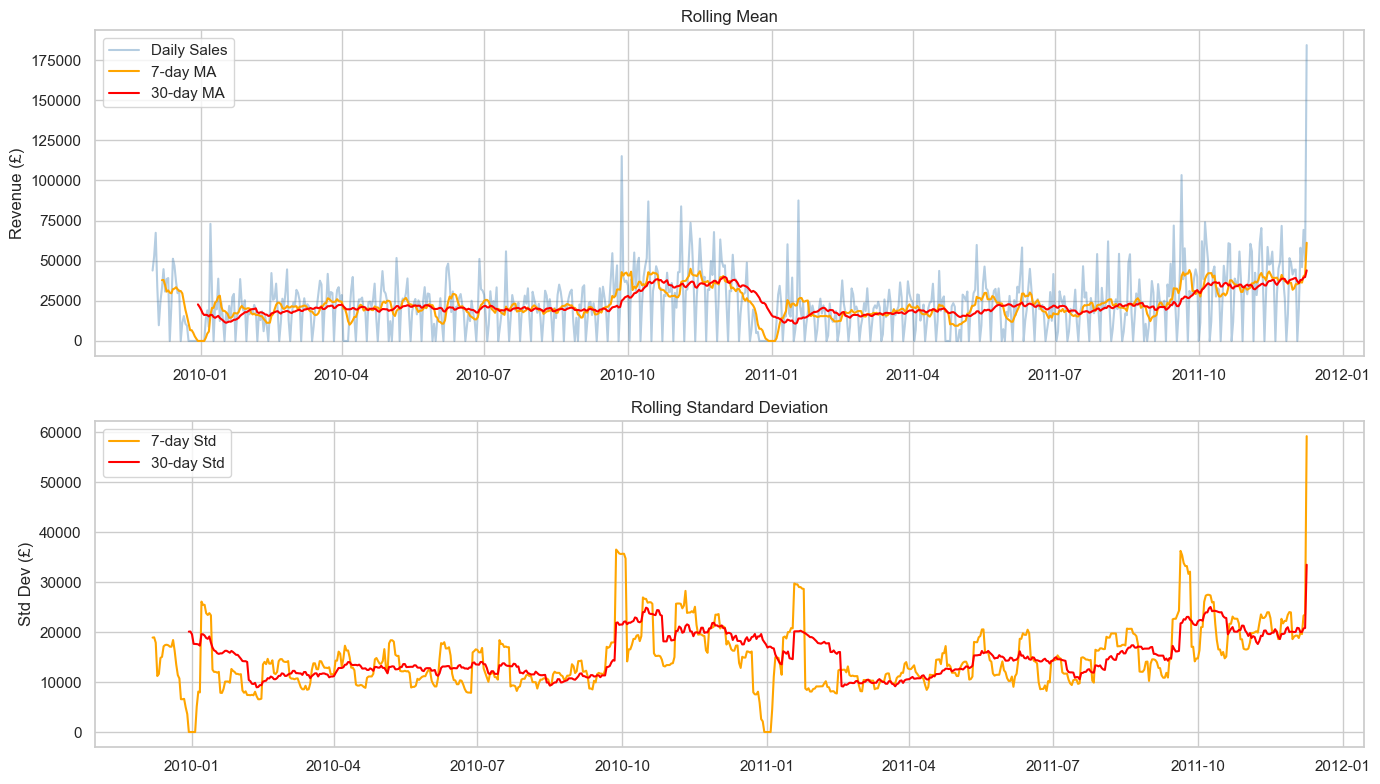

In [48]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# rolling mean
axes[0].plot(daily_sales['DailySales'],    alpha=0.4, label='Daily Sales', color='steelblue')
axes[0].plot(daily_sales['RollingMean7'],  label='7-day MA',  color='orange')
axes[0].plot(daily_sales['RollingMean30'], label='30-day MA', color='red')
axes[0].set_title('Rolling Mean')
axes[0].set_ylabel('Revenue (£)')
axes[0].legend()

# rolling std
axes[1].plot(daily_sales['RollingStd7'],  label='7-day Std',  color='orange')
axes[1].plot(daily_sales['RollingStd30'], label='30-day Std', color='red')
axes[1].set_title('Rolling Standard Deviation')
axes[1].set_ylabel('Std Dev (£)')
axes[1].legend()

plt.tight_layout()
plt.show()

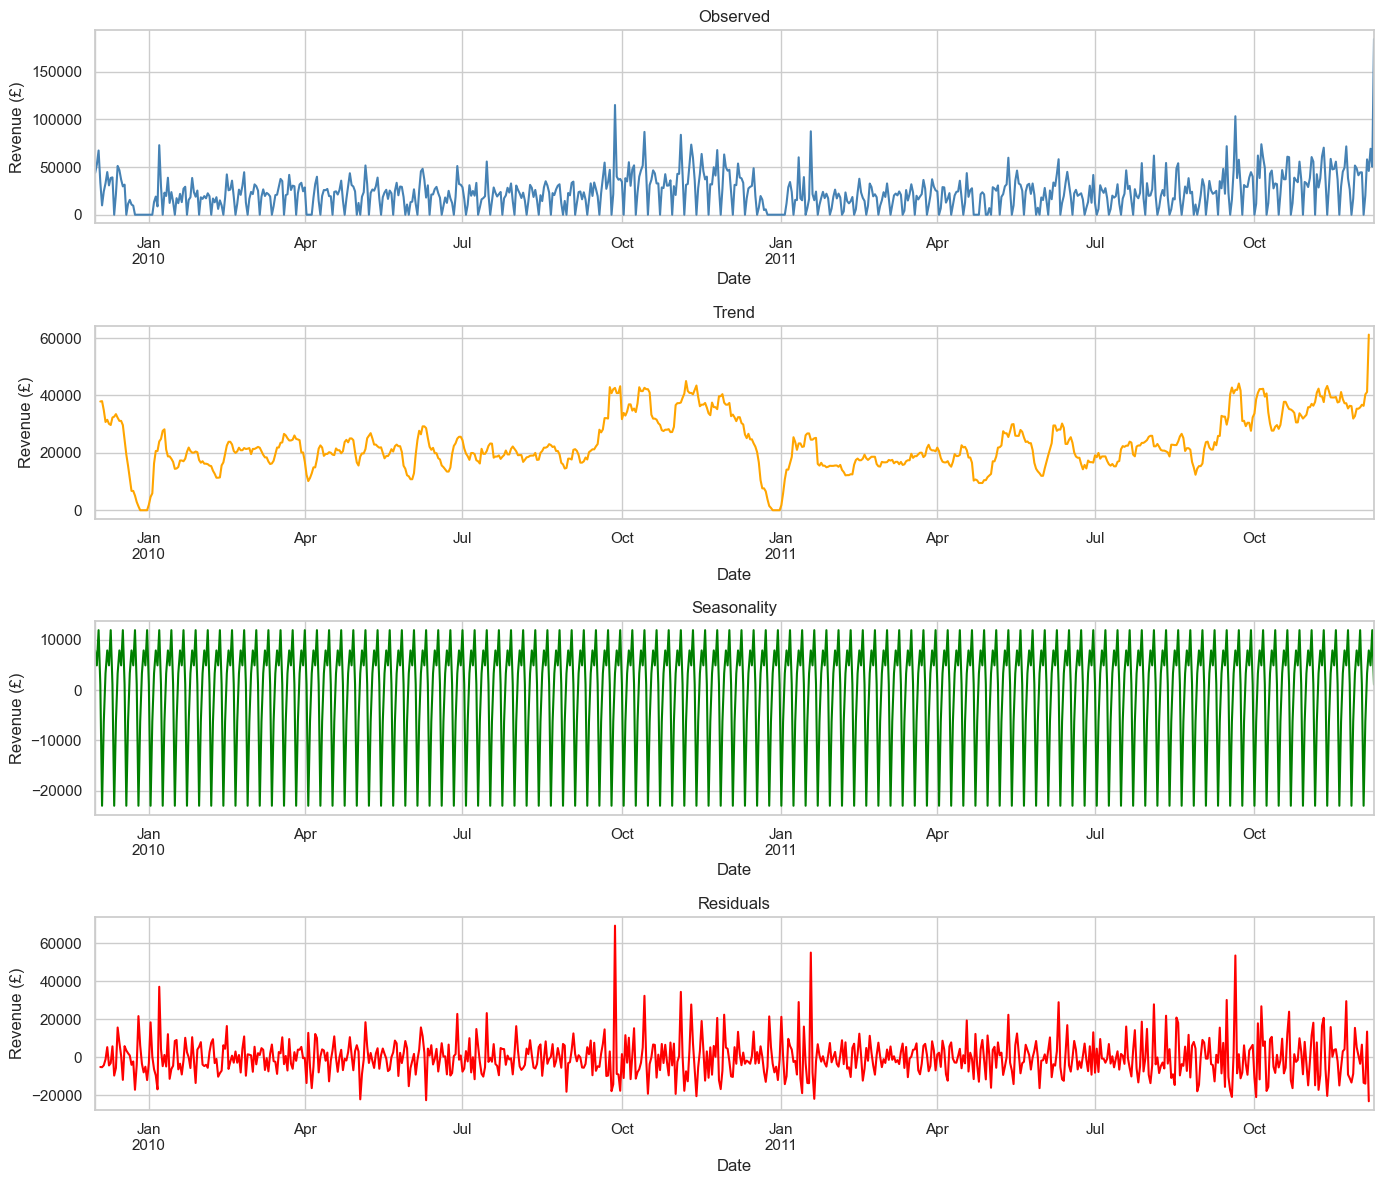

In [49]:
# seasonal decomposition — weekly period
decomp = seasonal_decompose(daily_sales['DailySales'], model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

decomp.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Observed')
axes[0].set_ylabel('Revenue (£)')

decomp.trend.plot(ax=axes[1], color='orange')
axes[1].set_title('Trend')
axes[1].set_ylabel('Revenue (£)')

decomp.seasonal.plot(ax=axes[2], color='green')
axes[2].set_title('Seasonality')
axes[2].set_ylabel('Revenue (£)')

decomp.resid.plot(ax=axes[3], color='red')
axes[3].set_title('Residuals')
axes[3].set_ylabel('Revenue (£)')

plt.tight_layout()
plt.show()

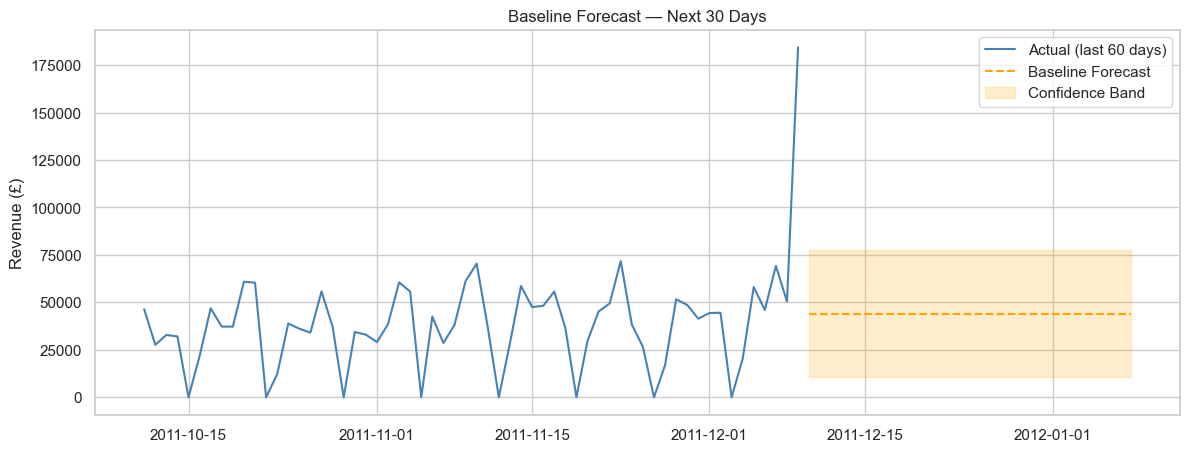

In [50]:
# baseline forecast plot
plt.figure(figsize=(14, 5))
plt.plot(daily_sales['DailySales'].tail(60), label='Actual (last 60 days)', color='steelblue')
plt.plot(future_df['BaselineForecast'], label='Baseline Forecast', color='orange', linestyle='--')
plt.fill_between(future_df.index, future_df['LowerBound'], future_df['UpperBound'], alpha=0.2, color='orange', label='Confidence Band')
plt.title('Baseline Forecast — Next 30 Days')
plt.ylabel('Revenue (£)')
plt.legend()
plt.show()

## 39. Export Refined Dataset

In [51]:
future_df.to_csv('../data/processed/baseline_forecast.csv')
print('Saved baseline_forecast.csv')

Saved baseline_forecast.csv


## 40. Refer Another Dataset

In [52]:
df_2 = pd.read_csv('../data/processed/cleaned_transactions.csv', parse_dates=['InvoiceDate'])
snapshot_date = df_2['InvoiceDate'].max()

print('Shape:', df_2.shape)
print('Snapshot date:', snapshot_date)

Shape: (779425, 16)
Snapshot date: 2011-12-09 12:50:00


## 41. RFM Calculation

In [53]:
rfm = df_2.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate',  lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice',      'nunique'),
    Monetary  = ('TotalPrice',   'sum')
).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print('RFM shape:', rfm.shape)
rfm.head()

RFM shape: (5878, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.00,325,12,77556.46
1,12347.00,1,8,4921.53
2,12348.00,74,5,2019.40
3,12349.00,18,4,4428.69
4,12350.00,309,1,334.40


## 42. RFM Dataset Preparation

In [54]:
print('RFM Summary:')
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2)

RFM Summary:


,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,200.33,6.29,2955.90
std,209.34,13.01,14440.85
min,0.00,1.00,2.95
25%,25.00,1.00,342.28
50%,95.00,3.00,867.74
75%,379.00,7.00,2248.30
max,738.00,398.00,580987.04


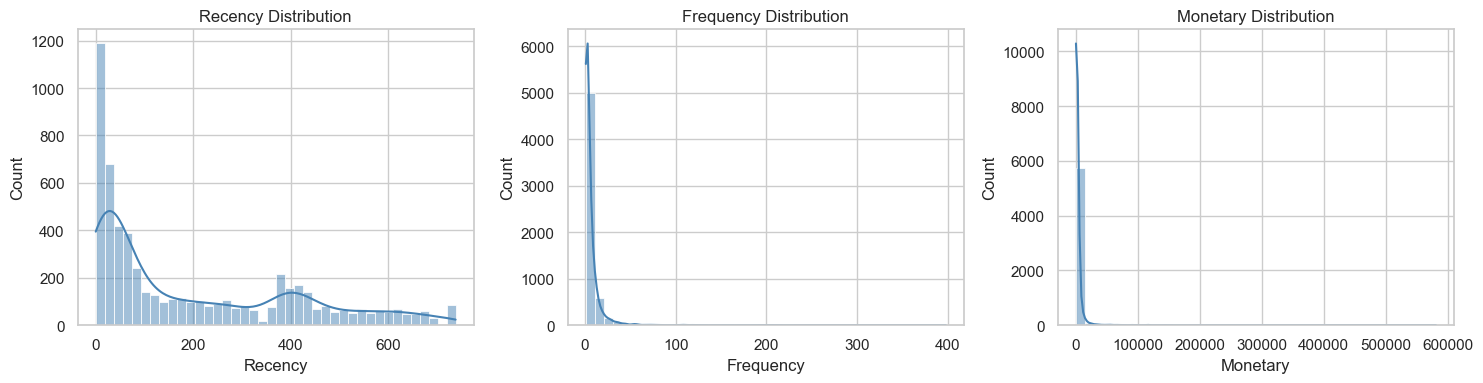

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm['Recency'],   bins=40, kde=True, ax=axes[0], color='steelblue').set_title('Recency Distribution')
sns.histplot(rfm['Frequency'], bins=40, kde=True, ax=axes[1], color='steelblue').set_title('Frequency Distribution')
sns.histplot(rfm['Monetary'],  bins=40, kde=True, ax=axes[2], color='steelblue').set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

## 43. Clustering Preparation

In [56]:
# check skewness before transformation
print('Skewness before transformation:')
print(rfm[['Recency', 'Frequency', 'Monetary']].skew().round(3))

Skewness before transformation:
Recency      0.89
Frequency   12.64
Monetary    25.07
dtype: float64


Skewness after log1p transformation:
Recency     0.89
Frequency   1.00
Monetary    0.27
dtype: float64


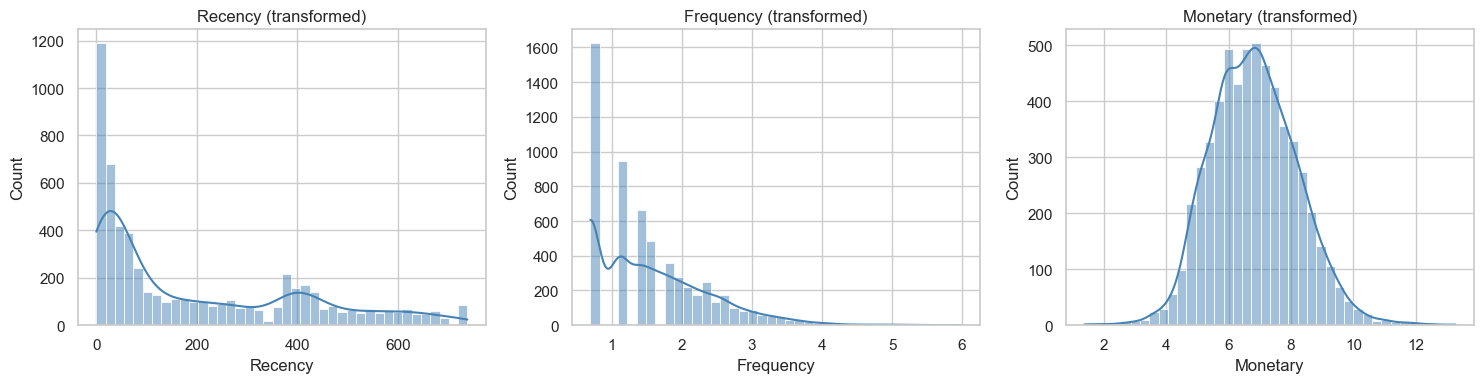

In [57]:
# log1p handles right-skewed distributions and avoids log(0)
rfm_transformed = rfm.copy()
rfm_transformed['Frequency'] = np.log1p(rfm_transformed['Frequency'])
rfm_transformed['Monetary']  = np.log1p(rfm_transformed['Monetary'])

print('Skewness after log1p transformation:')
print(rfm_transformed[['Recency', 'Frequency', 'Monetary']].skew().round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm_transformed['Recency'],   bins=40, kde=True, ax=axes[0], color='steelblue').set_title('Recency (transformed)')
sns.histplot(rfm_transformed['Frequency'], bins=40, kde=True, ax=axes[1], color='steelblue').set_title('Frequency (transformed)')
sns.histplot(rfm_transformed['Monetary'],  bins=40, kde=True, ax=axes[2], color='steelblue').set_title('Monetary (transformed)')

plt.tight_layout()
plt.show()

In [58]:
scaler = StandardScaler()
rfm_scaled = rfm_transformed.copy()
rfm_scaled[['Recency', 'Frequency', 'Monetary']] = scaler.fit_transform(
    rfm_transformed[['Recency', 'Frequency', 'Monetary']]
)

print('Scaled RFM — mean (should be ~0) and std (should be ~1):')
print(rfm_scaled[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'std']).round(3))
rfm_scaled.head()

Scaled RFM — mean (should be ~0) and std (should be ~1):
      Recency  Frequency  Monetary
mean    -0.00       0.00      0.00
std      1.00       1.00      1.00


,CustomerID,Recency,Frequency,Monetary
0,12346.00,0.60,1.25,3.21
1,12347.00,-0.95,0.80,1.22
2,12348.00,-0.60,0.30,0.57
3,12349.00,-0.87,0.07,1.14
4,12350.00,0.52,-1.06,-0.72


## 44. Refer Another Dataset

In [59]:
rfm.to_csv('../data/processed/rfm_dataset.csv', index=False)
rfm_scaled.to_csv('../data/processed/rfm_scaled.csv', index=False)

print('Saved.')
print(f'  rfm_dataset : {rfm.shape}')
print(f'  rfm_scaled  : {rfm_scaled.shape}')

Saved.
  rfm_dataset : (5878, 4)
  rfm_scaled  : (5878, 4)
